# Machine Learning + PLC Data

Posibles implementaciones de Machine Learning en sistemas de control basados en PLCs.: 

- XGBoost: arboles de deciion optimizados para predecir valores continuos y categoricos. minimiza el error cuadratico medio.
- Reinforcement Learning: 
    -  Deep Q-Learning (DQN)
Define estados como la temperatura actual, la posición de la válvula, etc.
Define acciones como aumentar/disminuir la válvula o modificar el setpoint.
Define recompensas en base a qué tan rápido se estabiliza el sistema.
    - Proximal Policy Optimization (PPO)
Más avanzado que DQN, aprende políticas óptimas para ajustar el sistema de manera más eficiente.

- Supervised Learning:
    - Regresión Lineal es un modelo simple que puede predecir valores continuos.
    - Regresión Logística: clasifica datos en dos categorías.
    - Redes Neuronales: modelos más complejos que pueden aprender patrones no lineales.
    - Random Forest: modelo de ensamble que puede manejar datos no lineales y no balanceados.

- Unsupervised Learning:
    - K-Means: agrupa datos en clusters.
    - PCA: reduce la dimensionalidad de los datos.
    - Autoencoders: aprenden representaciones latentes de los datos.

- Time Series:
    - ARIMA: modelo estadístico para predecir series temporales. Predice valor futuro en series temporales identificando patrones  de autocrrelacion y diferencias estacionales.
    - LSTM: red neuronal recurrente que puede predecir series temporales. Aprende dependencias a largo plazo en series temporales mediante puertas de memoria que controlan flujo de información.

- Anomaly Detection:
    - Isolation Forest: detecta anomalías en datos no balanceados. Aisla puntos atipicos construyendo arboles de decisión.
    - One-Class SVM: detecta anomalías en datos no balanceados.
    - Autoencoders: detecta anomalías en datos no balanceados.

- Por ver...
- Graficar anomalias tal vez en Grafana
- Predecir caracteristicas dado TT1501: entrena un modelo de Random Forest para predecir los valores óptimos de CV1801, MSC1600, TT1501, FT1501, TT1502, Pc_OIT_24Real[290] y Pc_OIT_24Real[291] para alcanzar el setpoint TT1501Pid. Luego, implementa un controlador que ajusta estas variables en tiempo real para alcanzar el setpoint. Asegúrate de ajustar el rango de valores según las especificaciones de tu sistema y manejar adecuadamente la comunicación con el PLC.




## 0. Librerías

In [118]:
#Librerias
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
from pylogix import PLC
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

## 1. Preprocesamiento de Datos

- Convertir datos de un archivo CSV a un DataFrame de Pandas
- Manejo valores faltantes/erroneos
- Nomrmalización o escalado

Realizo un dataframe inventando con 171 datos para cada TAG

In [56]:
# Definir el rango de fechas
start_date = datetime(2025, 2, 11, 17, 54, 59)
end_date = datetime(2025, 2, 18, 20, 30, 00)
date_range = pd.date_range(start=start_date, end=end_date, freq='H')

# Crear un DataFrame vacío
data = {
    '_start': [],
    '_stop': [],
    '_time': [],
    '_value': [],
    '_field': [],
    '_measurement': []
}

measurements = ['FT1501', 'Pc_OIT_24Real[291]', 'LT1503', 'TT1502', 'MSC1504', 'TT1501', 'MSC1001', 'CV1801', 'MSC1505','MSC1600','Pc_OIT_24Real[290]', 'TT1501Pid', 'LT1301', 'MSC1503', 'MSC1301', 'DeltaTPid']

# Generar datos sintéticos
for measurement in measurements:
    for date in date_range:
        data['_start'].append(start_date)
        data['_stop'].append(end_date)
        data['_time'].append(date)
        
        if measurement == 'TT1501Pid':
            data['_value'].append(194)  # Valor constante para TT1501Pid
        elif measurement == 'DeltaTPid':
            data['_value'].append(46)  # Valor constante para DeltaTPid
        elif measurement == 'CV1801':
            data['_value'].append(np.random.uniform(0,100))  # 0 A 100%
        elif measurement == 'FT1501':
            data['_value'].append(np.random.uniform(0,1000))  # 0 A 1000 L/min
        elif measurement == 'LT1301':
            data['_value'].append(np.random.uniform(0,1000))  # 0 A 1000 L
        elif measurement == 'LT1503':
            data['_value'].append(np.random.uniform(0,1000))  # 0 A 1000 L
        elif measurement == 'MSC1001' == 'MSC1301' == 'MSC1503' == 'MSC1504' == 'MSC1505' == 'MSC1600':
            data['_value'].append(np.random.uniform(0,100))  # 0 A 100 M/s
        elif measurement == 'Pc_OIT_24Real[290]':
            data['_value'].append(np.random.uniform(0, 500))
        elif measurement == 'Pc_OIT_24Real[291]':
            data['_value'].append(np.random.uniform(0, 300))
        elif measurement == 'TT1502'=='TT1501':
            data['_value'].append(np.random.uniform(0, 300))
        
        else:
            data['_value'].append(np.random.randn())  # Valores aleatorios para otros measurements
        
        if measurement == 'CV1801':
            data['_field'].append('VALUE')
        elif measurement == 'TT1501Pid':
            data['_field'].append('PID_SpRtn')
        elif measurement == 'DeltaTPid':
            data['_field'].append('PID_SP')
        elif measurement == 'MSC1600'=='MSC1504'=='MSC1505'=='MSC1503'=='MSC1301'=='MSC1001':
            data['_field'].append('SPSEgu')
        #elif measurement == 'Pc_OIT_24Real[290]'=='Pc_OIT_24Real[291]':
        #    data['_field'].append('')
        else:
            data['_field'].append('Value')
        data['_measurement'].append(measurement)

# Crear el DataFrame
df = pd.DataFrame(data)

# Mostrar el DataFrame
print(df.shape)
print(df.head())

# Guardar el DataFrame en un archivo CSV
df.to_csv('data_sintetica.csv', index=False)

(2736, 6)
               _start               _stop               _time      _value  \
0 2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 17:54:59  112.559529   
1 2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 18:54:59  353.553202   
2 2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 19:54:59  583.872768   
3 2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 20:54:59  419.410639   
4 2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 21:54:59  144.728106   

  _field _measurement  
0  Value       FT1501  
1  Value       FT1501  
2  Value       FT1501  
3  Value       FT1501  
4  Value       FT1501  


Pongo en columnas cada TAG con sus values como valores.

In [57]:
# Pivotar el DataFrame para tener columnas de cada medición y el campo
df_pivoted = df.pivot_table(index=['_start', '_stop', '_time'], columns='_measurement', values='_value')

# Restablecer el índice para que '_start', '_stop', '_time' y '_field' sean columnas
df_pivoted.reset_index(inplace=True)

# Mostrar el DataFrame resultante
print(df_pivoted.head())

_measurement              _start               _stop               _time  \
0            2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 17:54:59   
1            2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 18:54:59   
2            2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 19:54:59   
3            2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 20:54:59   
4            2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 21:54:59   

_measurement     CV1801  DeltaTPid      FT1501      LT1301      LT1503  \
0             80.118363       46.0  112.559529  851.725851  394.980750   
1             50.083477       46.0  353.553202  652.287351  516.384763   
2             91.945797       46.0  583.872768  387.683120  746.930823   
3             74.932535       46.0  419.410639  446.520286  625.935199   
4             15.706290       46.0  144.728106  195.404401  476.984981   

_measurement   MSC1001   MSC1301   MSC1503   MSC1504   MSC1505   MSC1600  \
0            -1.051183

### Esto para cuando usamos la bdd de InfluxDB

In [58]:
data = pd.read_csv('data.csv', skiprows=3)

df = pd.DataFrame(data)
print(df)

    Unnamed: 0  result  table                          _start  \
0          NaN     NaN      0  2025-02-11T17:54:59.757565989Z   
1          NaN     NaN      1  2025-02-11T17:54:59.757565989Z   
2          NaN     NaN      2  2025-02-11T17:54:59.757565989Z   
3          NaN     NaN      3  2025-02-11T17:54:59.757565989Z   
4          NaN     NaN      4  2025-02-11T17:54:59.757565989Z   
5          NaN     NaN      6  2025-02-11T17:54:59.757565989Z   
6          NaN     NaN      7  2025-02-11T17:54:59.757565989Z   
7          NaN     NaN      8  2025-02-11T17:54:59.757565989Z   
8          NaN     NaN      9  2025-02-11T17:54:59.757565989Z   
9          NaN     NaN     10  2025-02-11T17:54:59.757565989Z   
10         NaN     NaN     11  2025-02-11T17:54:59.757565989Z   
11         NaN     NaN     12  2025-02-11T17:54:59.757565989Z   
12         NaN     NaN     13  2025-02-11T17:54:59.757565989Z   
13         NaN     NaN     14  2025-02-11T17:54:59.757565989Z   
14         NaN     NaN   

In [59]:
# Drop the columns 'Unnamed: 0' and 'result'
df = df.drop(columns=['result'])
df = df.drop(columns=['Unnamed: 0'])

# Display the DataFrame
print(df)

    table                          _start                           _stop  \
0       0  2025-02-11T17:54:59.757565989Z  2025-02-18T17:54:59.757565989Z   
1       1  2025-02-11T17:54:59.757565989Z  2025-02-18T17:54:59.757565989Z   
2       2  2025-02-11T17:54:59.757565989Z  2025-02-18T17:54:59.757565989Z   
3       3  2025-02-11T17:54:59.757565989Z  2025-02-18T17:54:59.757565989Z   
4       4  2025-02-11T17:54:59.757565989Z  2025-02-18T17:54:59.757565989Z   
5       6  2025-02-11T17:54:59.757565989Z  2025-02-18T17:54:59.757565989Z   
6       7  2025-02-11T17:54:59.757565989Z  2025-02-18T17:54:59.757565989Z   
7       8  2025-02-11T17:54:59.757565989Z  2025-02-18T17:54:59.757565989Z   
8       9  2025-02-11T17:54:59.757565989Z  2025-02-18T17:54:59.757565989Z   
9      10  2025-02-11T17:54:59.757565989Z  2025-02-18T17:54:59.757565989Z   
10     11  2025-02-11T17:54:59.757565989Z  2025-02-18T17:54:59.757565989Z   
11     12  2025-02-11T17:54:59.757565989Z  2025-02-18T17:54:59.757565989Z   

## 2. Predecir TT1501 dado caracteristicas

Predecir la temperatura de salida del intercambiador TT1501 basada en las caracteristicas. Aprendera la relacion entre las caracterisitcas y la temperatura de salida del intercambiador. 

Asi permite ajustar las caracteristicas para alcanzar el setpoint deseado.
Aprendiendo la relacion entre las caracteristicas y la temperatura de salida del intercambiador, se puede ajustar las caracteristicas para alcanzar el setpoint deseado.

- Preprocesamiento de Datos

In [60]:
# Cargar datos
df = df_pivoted

# Seleccionar características y etiquetas
features = df[['CV1801', 'MSC1600', 'TT1501', 'FT1501', 'TT1502', 'Pc_OIT_24Real[290]', 'Pc_OIT_24Real[291]']]
#target = df['TT1501Pid']
target = df['TT1501']


# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

- Imprimo conjunto de entrenamiento y preuba para observar como van los valores

In [ ]:
print(X_train)
print(X_test)

_measurement     CV1801   MSC1600    TT1501      FT1501    TT1502  \
100            9.045675 -1.708176  1.181045   55.332122  0.403165   
75            46.513761 -2.734352  1.399296  667.049177  0.629314   
42            51.004228  0.571275  0.525207  906.999111  0.646560   
2             91.945797  1.616647  1.434211  583.872768  0.926968   
95            96.731718 -1.649521  0.036152  603.555004  0.328840   
..                  ...       ...       ...         ...       ...   
71            81.629124  0.844022  0.751792  499.569817  0.833655   
106           91.713481  1.039920 -0.104760  318.897545  0.500616   
14            20.614178  1.664691  0.072993  328.703552 -0.676168   
92            59.570217 -0.126382  0.118281  415.244695  0.213349   
102           45.002067  0.188466  0.653824  675.526624 -0.944718   

_measurement  Pc_OIT_24Real[290]  Pc_OIT_24Real[291]  
100                   123.419730          296.786472  
75                     18.375172           45.384381  
42    

- Entrenamiento del modelo

Mientras mas bajo el mse mejor es el modelo de prediccion de la temperatura de salida del intercambiador.

In [62]:
# Entrenar el modelo
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Evaluar el modelo
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.010576919997636538


- Vista de chequeo observando el valor real con el predicho para dicho tiempo

Itera sobre valores de y_test (valores reales) y y_pred (valores predichos) junto con su tiempo. El zip combina los tiempos(indice de y_test), valores reales (y_test) y valores predichos (y_pred).

Grafico de dispresion de y_test frente y_pred. Mientras mas cerca de la linea de 45 grados mejor es el modelo. La lina de referencia en rojo representa una prediccion perfecta (donde valores reales son =s a valores predichos)

Tiempo: 101, Valor Real: -2.2512573861282403, Valor Predicho: -2.220516424545216
Tiempo: 55, Valor Real: 2.2854922116081853, Valor Predicho: 2.216399021779081
Tiempo: 56, Valor Real: -0.5599186475507159, Valor Predicho: -0.5400090146740293
Tiempo: 139, Valor Real: 0.41548374649582814, Valor Predicho: 0.4094281975525508
Tiempo: 157, Valor Real: 0.5765334110571158, Valor Predicho: 0.5590014213474521
Tiempo: 78, Valor Real: 0.3860904234575364, Valor Predicho: 0.3890311787190885
Tiempo: 135, Valor Real: -0.3078548201815047, Valor Predicho: -0.32499678786469594
Tiempo: 104, Valor Real: 0.36401453693218816, Valor Predicho: 0.36935543949904753
Tiempo: 109, Valor Real: -0.9699281971733777, Valor Predicho: -1.036253460669481
Tiempo: 108, Valor Real: 2.8636069471975594, Valor Predicho: 2.2808499557688093
Tiempo: 162, Valor Real: 0.8626168553142647, Valor Predicho: 0.8782830674660614
Tiempo: 137, Valor Real: -1.0104701860908631, Valor Predicho: -1.0624159363816854
Tiempo: 51, Valor Real: 0.243552

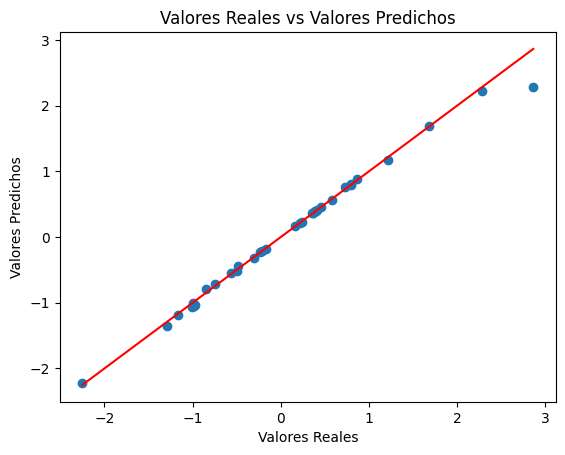

In [63]:
# Imprimir los valores reales y predichos con sus tiempos
for time, real, pred in zip(y_test.index, y_test, y_pred):
    print(f"Tiempo: {time}, Valor Real: {real}, Valor Predicho: {pred}")

# Gráfico de dispersión de valores reales vs predichos
plt.scatter(y_test, y_pred)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Valores Reales vs Valores Predichos')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Línea de referencia
plt.show()

R^2: 0.989712948938783


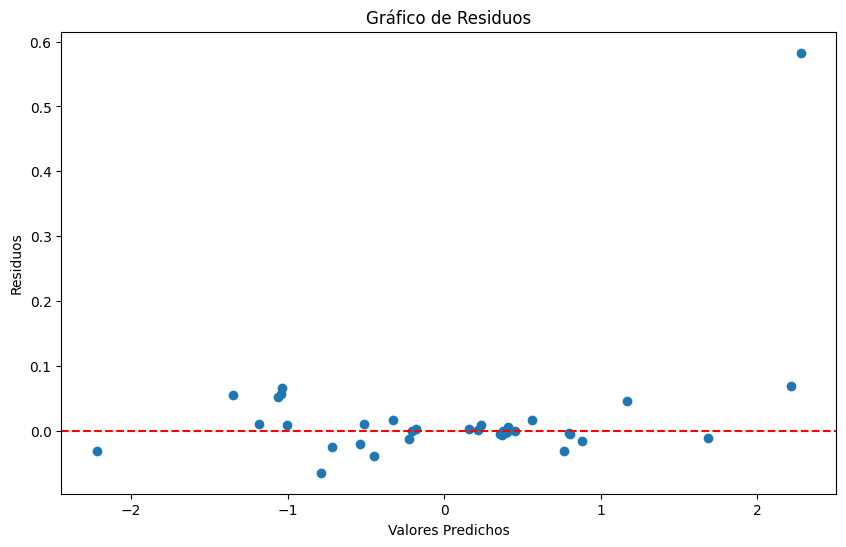

In [ ]:
# Calcular el coeficiente de determinación R^2 
#R^2 es una medida estadística de qué tan cerca están los datos de la línea de regresión ajustada.
# la linea de regresio ajustada es la linea que mejor se ajusta a los datos

r2 = r2_score(y_test, y_pred)
print(f'R^2: {r2}')

# Calcular los residuos
residuals = y_test - y_pred

# Graficar los residuos
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals) # Gráfico de dispersión de valores predichos vs residuos
plt.axhline(y=0, color='r', linestyle='--') # Línea base en y=0
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos')
plt.show()

- Implementación Controlador

In [ ]:
def predict_optimal_values(current_conditions):
    # Escalar las condiciones actuales
    current_conditions_scaled = scaler.transform([current_conditions])
    
    # Predecir el valor óptimo para alcanzar el setpoint
    predicted_values = .modelpredict(current_conditions_scaled)
    
    return predicted_values

In [ ]:
# Ejemplo de uso

#[CV1801, MSC1600, TT1501, FT1501, TT1502, Pc_OIT_24Real[290], Pc_OIT_24Real[291]]
current_conditions = [56, 80, 100, 566, 29, 300,240]  # Valores actuales de CV1801, MSC1600, TT1501, FT1501, TT1502, Pc_OIT_24Real[290], Pc_OIT_24Real[291]
optimal_values = predict_optimal_values(current_conditions)
print(f'Condiciones actuales: {current_conditions}')
print(f'Valores óptimo predicho para TT1501: {optimal_values}')


Condiciones actuales: [56, 80, 100, 566, 29, 300, 240]
Valores óptimo predicho para TT1501: [2.32626175]


c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 3. Integración con PLC

In [ ]:
def get_current_conditions():
    with PLC() as plc:
        plc.IPAddress = '192.168.1.10'
        cv1801 = plc.Read('CV1801').Value #VALUE
        msc1600 = plc.Read('MSC1600').Value #SPESegu
        tt1501 = plc.Read('TT1501').Value
        ft1501 = plc.Read('FT1501').Value
        tt1502 = plc.Read('TT1502').Value
        pc_oit_24real290 = plc.Read('Pc_OIT_24Real[290]').Value
        pc_oit_24real291 = plc.Read('Pc_OIT_24Real[291]').Value
        #se pueden poner mas variables
    return [cv1801, msc1600, tt1501, ft1501, tt1502, pc_oit_24real290, pc_oit_24real291]

def send_to_plc(cv1801, msc1600):
    with PLC() as plc:
        plc.IPAddress = '192.168.1.10'
        plc.Write('CV1801', cv1801)
        plc.Write('MSC1600', msc1600)
        #se pueden poner mas variables


In [ ]:
# Obtener valores actuales
current_conditions = get_current_conditions()
# Predecir valores óptimos por ejemplo el usado de antes
optimal_value = predict_optimal_values(current_conditions)
# Enviar valores óptimos al PLC
send_to_plc(optimal_value)

## 4. SP Intercambiador

- Preprocesar Datos para LSTM

In [ ]:
# Seleccionar las series temporales de interés
series_temp_intercambiador = df_pivoted['TT1501'] #temperatura del intercambiador
series_valvula_gas = df_pivoted['CV1801'] #valvula gas
series_temp_camara = df_pivoted['Pc_OIT_24Real[291]'] #temperatura de la camara intercambiador

# Normalizar los datos DE 0 A 1
scaler = MinMaxScaler(feature_range=(0, 1))
series_temp_intercambiador_scaled = scaler.fit_transform(series_temp_intercambiador.values.reshape(-1, 1))
series_valvula_gas_scaled = scaler.fit_transform(series_valvula_gas.values.reshape(-1, 1))
series_temp_camara_scaled = scaler.fit_transform(series_temp_camara.values.reshape(-1, 1))

# Crear secuencias de datos para el modelo LSTM
def create_sequences(data, seq_length): #toma una serie de datos y una longitud de secuencia
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences) #devuelve una lista de secuencias de longitud seq_length. Cada secuencia es una subsecuencia de la serie de datos original

# generar secuencias para cada serie temporal
seq_length = 10
sequences_temp_intercambiador = create_sequences(series_temp_intercambiador_scaled, seq_length)
sequences_valvula_gas = create_sequences(series_valvula_gas_scaled, seq_length)
sequences_temp_camara = create_sequences(series_temp_camara_scaled, seq_length)

# Concatenar todas las secuencias
# cada secuecia tiene 3 columnas(SP temp intercambiador, posicion valvula de gas y temp camara intermbiador), una para cada serie temporal
sequences = np.concatenate([sequences_temp_intercambiador, sequences_valvula_gas, sequences_temp_camara], axis=2)

# Dividir los datos en entrenamiento y prueba
train_size = int(len(sequences) * 0.8)
train_sequences, test_sequences = sequences[:train_size], sequences[train_size:]

# Separar características y etiquetas
X_train = train_sequences[:, :-1] #Caracteristicas del conjunto train, todas las secuencias menos la ultima
y_train = train_sequences[:, -1, 0]  # Usamos la temperatura del intercambiador como etiqueta, utlimo valor de temp del intercambiador en c/secuencia
X_test = test_sequences[:, :-1]
y_test = test_sequences[:, -1, 0]

Esto normalizo las series temporales, creo secuencias de datos y se dividio en conjuntos de entrenamiento y prueba.

- construir y entrenar modelo

LSTM: Long Short-Term Memory. Capaz de aprender dependencias temporales en los datos. 

**LSTM(50, return_sequences=True, input_shape=(seq_length - 1, 3)):** 50 unidades, la capa LSTM debe devolver la secuencia completa de salida para cada entrada, especifica la forma de la entrada donde seq_length - 1 es la longitud de la secuencia y 3 es el número de características (temperatura del intercambiador, posición de la válvula de gas y temperatura de la cámara del intercambiador).

LSTM tiene 50 celdas de memoria y, por lo tanto, puede aprender 50 patrones o características diferentes de los datos secuenciales. 

**Dropout(0.2):** Añade una capa de dropout con una tasa de 0.2. El 20% de las unidades de la capa anterior se desactivarán aleatoriamente durante el entrenamiento para prevenir el sobreajuste.

**LSTM(50, return_sequences=False):** Añade otra capa LSTM con 50 unidades. return_sequences=False indica que esta capa LSTM debe devolver solo la última salida en la secuencia de salida.

**Dense(1):** Añade una capa densa con una unidad de salida. Esta capa se utiliza para producir la predicción final del modelo.

In [121]:
# Construir el modelo LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_length - 1, 3)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

#compilar el modelo
# adam para actualizar los pesos del modelo durante training
# loss= mean squared error, uso esta como fucnion de perdida, mide la dif promedio al cuadrado entre las predicciones del modelo y los valores reales. 
model.compile(optimizer='adam', loss='mean_squared_error')

# Entrenar el modelo
# 20 iteraciones sobre conjunto training
# batch_size=32, tamaño de lote, numero de muestras que se usan para actualizar los pesos del modelo
# validation_data=(X_test, y_test), conjunto de validacion
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
4/4 [==============================] - 4s 294ms/step - loss: 0.2634 - val_loss: 0.1385
Epoch 2/20
4/4 [==============================] - 0s 20ms/step - loss: 0.1000 - val_loss: 0.0356
Epoch 3/20
4/4 [==============================] - 0s 19ms/step - loss: 0.0484 - val_loss: 0.0612
Epoch 4/20
4/4 [==============================] - 0s 19ms/step - loss: 0.0623 - val_loss: 0.0474
Epoch 5/20
4/4 [==============================] - 0s 19ms/step - loss: 0.0492 - val_loss: 0.0305
Epoch 6/20
4/4 [==============================] - 0s 23ms/step - loss: 0.0405 - val_loss: 0.0351
Epoch 7/20
4/4 [==============================] - 0s 21ms/step - loss: 0.0496 - val_loss: 0.0380
Epoch 8/20
4/4 [==============================] - 0s 21ms/step - loss: 0.0433 - val_loss: 0.0334
Epoch 9/20
4/4 [==============================] - 0s 19ms/step - loss: 0.0398 - val_loss: 0.0303
Epoch 10/20
4/4 [==============================] - 0s 18ms/step - loss: 0.0397 - val_loss: 0.0318
Epoch 11/20
4/4 [===========

- loss: funncion de perdida en conjunto de train. 
- val_loss: funcion de perdiad en conjunto de validacion.

Pérdida Baja: Se busca que tanto la pérdida de entrenamiento (loss) como la pérdida de validación (val_loss) sean lo más bajas posible. Esto indica que el modelo está haciendo buenas predicciones tanto en los datos de entrenamiento como en los de validación.


Consistencia: Se busca que la pérdida de validación no aumente significativamente en comparación con la pérdida de entrenamiento. Un aumento significativo en la pérdida de validación puede ser una señal de sobreajuste, donde el modelo está memorizando los datos de entrenamiento en lugar de aprender patrones generales.

- Hacer Predicciones y Ajustar Válvula de Gas

Se usa el moedlo LSTM entrenado para hacer predcicciones sobre X_test. Esto luego me da un array de predicciones para cada secuencia en el conjunto de prueba. 

- **inverse_transform:** Se invierte la normalizacion de las predicciones y los valores reales para compararlos. Necesario porque los datos fueron normalizados antes de ser usados en el modelo. 
- **reshape(-1, 1):** Cambia la forma de los datos a un vector columna. Reorganizo y_test en una matriz de 2 dimensiones con 1 columna, para aplicar transofrmacion inversa.

Se ajusta la valuvla de gas en el PLC a los valores predicios por el moedelo LSTM.



In [122]:
# Hacer predicciones
predictions = model.predict(X_test)

# Invertir la normalización
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Función para ajustar la válvula de gas en el PLC
def adjust_valve(plc_ip, tag_name, new_value): # funcion para ajustar la valvula de gas en el PLC
    with PLC() as comm:
        comm.IPAddress = plc_ip # IP PLC
        comm.Write(tag_name, new_value) #escribe nuevo valor en el tag del plc
        print(f"Válvula de gas ajustada a: {new_value}") #imprime el valor ajustado

# Ajustar la válvula de gas en función de las predicciones
plc_ip = "aaa.bbb.ccc.ddd"
tag_name = "CV1801.VALUE"
for i in range(len(predictions)): #itero sobre predicciones y llamo a funcion adjust_valve
    #para ajustar la valula de gas en el PLC con el valor predicho correspondiene
    adjust_valve(plc_ip, tag_name, predictions[i][0])

2/2 [==============================] - 1s 6ms/step
Válvula de gas ajustada a: 176.23944091796875
Válvula de gas ajustada a: 173.0146942138672
Válvula de gas ajustada a: 169.3680877685547
Válvula de gas ajustada a: 165.0413818359375
Válvula de gas ajustada a: 160.94044494628906
Válvula de gas ajustada a: 154.7200164794922
Válvula de gas ajustada a: 146.191650390625
Válvula de gas ajustada a: 145.56710815429688
Válvula de gas ajustada a: 143.94041442871094
Válvula de gas ajustada a: 138.34886169433594
Válvula de gas ajustada a: 144.12298583984375
Válvula de gas ajustada a: 146.3826904296875
Válvula de gas ajustada a: 149.89712524414062
Válvula de gas ajustada a: 156.29591369628906
Válvula de gas ajustada a: 160.4956512451172
Válvula de gas ajustada a: 165.10568237304688
Válvula de gas ajustada a: 162.8310089111328
Válvula de gas ajustada a: 158.72418212890625
Válvula de gas ajustada a: 160.39073181152344
Válvula de gas ajustada a: 157.43353271484375
Válvula de gas ajustada a: 157.6743927

- Detectar anomalias en la temperatura del intercambiador

In [125]:
import numpy as np

# Valor general que no es una anomalía (media de los valores reales)
general_value = np.mean(y_test)
print(f"Valor general que no es una anomalía: {general_value}")

# Detectar anomalías
threshold = 2 * np.std(y_test)  # desviación estándar por 2 para umbral de anomalía
# así se determina qué tan lejos debe estar una predicción del valor real para ser considerada una anomalía
anomalies_lstm = np.abs(y_test - predictions) > threshold
# diferencia absoluta entre valores reales y predicciones
# si la diferencia es mayor al umbral, se considera una anomalía, esto es un array booleano donde True indica una anomalía

# Mostrar las anomalías
anomalies_indices = np.where(anomalies_lstm)[0]  # obtengo los True del array
# accede al índice de la serie temporal original donde se detectó una anomalía,
# anomalies_times es un array con los tiempos de las anomalías
anomalies_times = y.index[train_size + seq_length + anomalies_indices]
anomalies_values = y_test[anomalies_indices]

print("Anomalías detectadas en los siguientes tiempos y valores:")
for time, value in zip(anomalies_times, anomalies_values):
    print(f"Tiempo: {time}, Valor: {value}")

Valor general que no es una anomalía: 160.1694832575553
Anomalías detectadas en los siguientes tiempos y valores:
Tiempo: 149, Valor: [270.9630448]
Tiempo: 159, Valor: [275.30700014]


## 5. Detección de Anomalías

- UMBRALES FIJOS

Con los valores esperados, defino rangos seguros y detecto valores fuera de rango.

In [129]:
def detect_anomaly(value, lower, upper):
    return value < lower or value > upper

df_pivoted["Anomaly MSC1301"] = df_pivoted["MSC1301"].apply(lambda x: detect_anomaly(x, -2, 2))
print(df_pivoted['Anomaly MSC1301'].value_counts())



Anomaly MSC1301
False    166
True       5
Name: count, dtype: int64


In [130]:
anomalies = df_pivoted[df_pivoted["Anomaly MSC1301"] == True]
print(anomalies)

_measurement              _start               _stop               _time  \
3            2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-11 20:54:59   
87           2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-15 08:54:59   
89           2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-15 10:54:59   
109          2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-16 06:54:59   
140          2025-02-11 17:54:59 2025-02-18 20:30:00 2025-02-17 13:54:59   

_measurement     CV1801  DeltaTPid      FT1501      LT1301      LT1503  \
3             74.932535       46.0  419.410639  446.520286  625.935199   
87            43.440069       46.0    2.065942  271.985038  646.793050   
89             8.819573       46.0  511.739068  179.184072  980.327376   
109            6.162406       46.0  396.046335  110.239964  995.505249   
140           48.512212       46.0   88.868813  637.582950  613.218928   

_measurement   MSC1001   MSC1301   MSC1503   MSC1504   MSC1505   MSC1600  \
3             0.382170

- Isolation Forest, detecta anomalias en datos multidimiensionales.
- Autoencoders, redes neuronales para deteciión de anomalias.
- ARIMA/LSTMs, deteccion de anomalias con prediccion de series temporales. 

### LSTM

In [136]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import numpy as np


# Seleccionar la serie temporal de interés
series = df_pivoted.set_index('_time')['TT1501']

# Normalizar los datos
scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series.values.reshape(-1, 1))

# Crear secuencias de datos para el modelo LSTM
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences)

seq_length = 10
sequences = create_sequences(series_scaled, seq_length)

# Dividir los datos en entrenamiento y prueba
train_size = int(len(sequences) * 0.8)
train_sequences, test_sequences = sequences[:train_size], sequences[train_size:]

# Separar características y etiquetas
X_train = train_sequences[:, :-1]
y_train = train_sequences[:, -1]
X_test = test_sequences[:, :-1]
y_test = test_sequences[:, -1]

# Construir el modelo LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_length - 1, 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Entrenar el modelo
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Hacer predicciones
predictions = model.predict(X_test)

# Invertir la normalización
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test)

# Detectar anomalías
threshold = 2 * np.std(y_test)
anomalies_lstm = np.abs(y_test - predictions) > threshold

# Mostrar las anomalías
anomalies_indices = np.where(anomalies_lstm)[0]
anomalies_times = series.index[train_size + seq_length + anomalies_indices]
print("Anomalías detectadas en los siguientes tiempos:")
print(anomalies_times)

Epoch 1/20
4/4 [==============================] - 4s 281ms/step - loss: 0.2139 - val_loss: 0.1313
Epoch 2/20
4/4 [==============================] - 0s 22ms/step - loss: 0.1013 - val_loss: 0.0410
Epoch 3/20
4/4 [==============================] - 0s 21ms/step - loss: 0.0508 - val_loss: 0.0448
Epoch 4/20
4/4 [==============================] - 0s 25ms/step - loss: 0.0547 - val_loss: 0.0426
Epoch 5/20
4/4 [==============================] - 0s 21ms/step - loss: 0.0457 - val_loss: 0.0307
Epoch 6/20
4/4 [==============================] - 0s 21ms/step - loss: 0.0414 - val_loss: 0.0326
Epoch 7/20
4/4 [==============================] - 0s 21ms/step - loss: 0.0408 - val_loss: 0.0345
Epoch 8/20
4/4 [==============================] - 0s 22ms/step - loss: 0.0435 - val_loss: 0.0319
Epoch 9/20
4/4 [==============================] - 0s 20ms/step - loss: 0.0415 - val_loss: 0.0304
Epoch 10/20
4/4 [==============================] - 0s 20ms/step - loss: 0.0442 - val_loss: 0.0309
Epoch 11/20
4/4 [===========

### ARIMA

c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
c:\Users\josef\AppData\Local\Programs\Python\Python38\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)


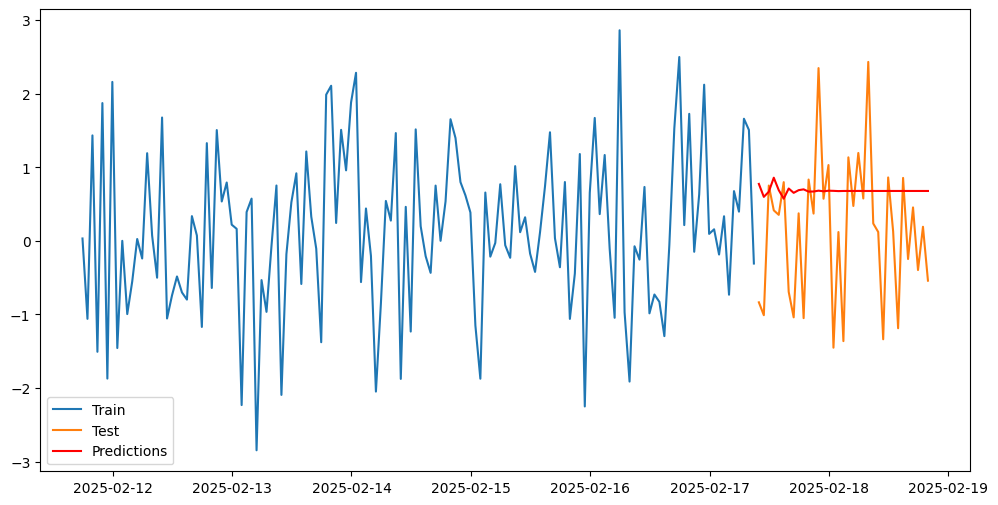

_time
2025-02-18 00:54:59   -1.452099
2025-02-18 02:54:59   -1.362964
2025-02-18 10:54:59   -1.337837
Name: TT1501, dtype: float64


In [137]:
from statsmodels.tsa.arima.model import ARIMA # type: ignore

import matplotlib.pyplot as plt

# Seleccionar la serie temporal de interés
series = df_pivoted.set_index('_time')['TT1501']

# Dividir los datos en entrenamiento y prueba
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

# Ajustar el modelo ARIMA
model = ARIMA(train, order=(5, 1, 0))
model_fit = model.fit()

# Hacer predicciones
predictions = model_fit.forecast(steps=len(test))

# Graficar los resultados
plt.figure(figsize=(12, 6))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(test.index, predictions, label='Predictions', color='red')
plt.legend()
plt.show()

# Detectar anomalías
anomalies_arima = test[(test - predictions).abs() > 2 * test.std()]
print(anomalies_arima)

### IsolationForest

In [140]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05)  # Suponiendo que el 5% de los datos son anomalías